# Surface Defect Detection — Baseline, Transfer Learning & Fine-Tuning
This notebook implements three experimental settings from `agent.md`:
1. **Baseline (Setting 1)**: A custom CNN from scratch
2. **Transfer Learning (Setting 2)**: A frozen ResNet-50 backbone with a new classification head
3. **Fine-Tuning with Aggressive Augmentation (Setting 3)**: Unfrozen ResNet-50 backbone with heavy data augmentation to simulate rugged field conditions

**Dataset**: Severstal Steel Defect Detection (Kaggle)
**Task**: Multi-label classification — given an image, predict which of 4 defect classes are present.
**Splits**: Persisted 80/10/10 train/val/test CSVs loaded from `data/`. Split is generated once and reused.

In [16]:
import os
import subprocess
import sys

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
import matplotlib.pyplot as plt

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Step 1 — Ensure Data Splits Exist
The split CSVs (`data/train_split.csv`, `data/val_split.csv`, `data/test_split.csv`) are generated
**once** by `split_data.py` and reused on every subsequent run. The Kaggle `test_images/` folder is
intentionally excluded because it has no ground-truth labels.

In [17]:
DATA_ROOT   = os.path.join(os.getcwd(), 'data')
IMG_DIR     = os.path.join(DATA_ROOT, 'severstal-steel-defect-detection', 'train_images')
TRAIN_CSV   = os.path.join(DATA_ROOT, 'train_split.csv')
VAL_CSV     = os.path.join(DATA_ROOT, 'val_split.csv')
TEST_CSV    = os.path.join(DATA_ROOT, 'test_split.csv')

# Generate splits only if they do not already exist
if not all(os.path.exists(p) for p in [TRAIN_CSV, VAL_CSV, TEST_CSV]):
    print('Split CSVs not found — running split_data.py ...')
    result = subprocess.run([sys.executable, 'split_data.py'], capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError('split_data.py failed. Check the output above.')
else:
    print('Split CSVs already exist — skipping split step.')

# Verify image directory
if not os.path.isdir(IMG_DIR):
    raise FileNotFoundError(
        f"Train images directory not found: {IMG_DIR}\n"
        "Make sure the dataset zip has been extracted to data/severstal-steel-defect-detection/"
    )

print(f"Train images directory: {IMG_DIR}")

Split CSVs already exist — skipping split step.
Train images directory: /home/blancjh/metal-defect-classification/data/severstal-steel-defect-detection/train_images


## Step 2 — Configuration

In [18]:
BATCH_SIZE    = 32
IMG_SIZE      = 224
NUM_CLASSES   = 4   # Severstal has 4 defect class IDs: 1, 2, 3, 4
EPOCHS        = 10

# Standard ImageNet normalisation (backbone-compatible)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

## Step 3 — Dataset
`SteelDefectDataset` reads the persisted split CSV and loads the corresponding image from `train_images/`.
Labels are **multi-hot** vectors of length 4 (one bit per defect class). An image with no annotation
in `train.csv` is treated as a **no-defect** sample (all zeros).

In [19]:
class SteelDefectDataset(Dataset):
    """Custom Dataset for the Severstal Steel Defect Detection competition.

    Args:
        csv_path  : Path to pre-generated split CSV (train / val / test).
        img_dir   : Path to folder containing train_images.
        transform : torchvision transforms pipeline.
    """

    def __init__(self, csv_path: str, img_dir: str, transform=None):
        df = pd.read_csv(csv_path)

        # Normalise image-id column
        if 'ImageId' in df.columns:
            id_col = 'ImageId'
        elif 'ImageId_ClassId' in df.columns:
            df['ImageId'] = df['ImageId_ClassId'].apply(lambda x: x.split('_')[0])
            df['ClassId'] = df['ImageId_ClassId'].apply(lambda x: int(x.split('_')[1]))
            id_col = 'ImageId'
        else:
            raise ValueError(f'Unexpected columns in {csv_path}: {list(df.columns)}')

        # Keep only rows that actually have a mask annotation
        df = df.dropna(subset=['EncodedPixels'])

        # Build a mapping: image_name -> multi-hot label vector
        self.label_map: dict[str, np.ndarray] = {}
        for img_name, grp in df.groupby(id_col):
            label = np.zeros(NUM_CLASSES, dtype=np.float32)
            for cls_id in grp['ClassId'].astype(int):
                if 1 <= cls_id <= 4:
                    label[cls_id - 1] = 1.0   # cls_id 1-4 → index 0-3
            self.label_map[img_name] = label

        # All unique image names in this split (including no-defect images)
        all_imgs = pd.read_csv(csv_path)[id_col if id_col == 'ImageId' else 'ImageId_ClassId']
        if id_col == 'ImageId_ClassId':
            all_imgs = all_imgs.apply(lambda x: x.split('_')[0])
        self.image_names = list(all_imgs.unique())

        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self) -> int:
        return len(self.image_names)

    def __getitem__(self, idx: int):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Retrieve multi-hot label (default = all-zeros if not in label_map)
        label = self.label_map.get(img_name, np.zeros(NUM_CLASSES, dtype=np.float32))
        return image, torch.tensor(label, dtype=torch.float32)


# --- Build datasets and loaders ---
train_dataset = SteelDefectDataset(TRAIN_CSV, IMG_DIR, transform=train_transform)
val_dataset   = SteelDefectDataset(VAL_CSV,   IMG_DIR, transform=eval_transform)
test_dataset  = SteelDefectDataset(TEST_CSV,  IMG_DIR, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train: {len(train_dataset)} images | Val: {len(val_dataset)} images | Test: {len(test_dataset)} images")

Train: 5332 images | Val: 667 images | Test: 667 images


---
# Baseline (Experimental Setting 1)
A simple, custom Convolutional Neural Network (CNN) built from scratch.
This proves understanding of the core mechanics before leveraging pretrained models.

## Step 4 — Network Architecture
A lightweight custom CNN with 3 conv blocks, suitable for a first-pass feasibility study.

In [20]:
class BaselineCNN(nn.Module):
    """Simple CNN from scratch for multi-label defect classification."""

    def __init__(self, num_classes: int = 4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),  # 112×112
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2), # 56×56
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2), # 28×28
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
            # NOTE: No Sigmoid here — BCEWithLogitsLoss handles it for numerical stability.
        )

    def forward(self, x):
        return self.classifier(self.features(x))


baseline_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
baseline_criterion = nn.BCEWithLogitsLoss()   # multi-label binary cross-entropy
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3)

print(baseline_model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=4, bias=True)
  )
)


## Step 5 — Training Loop (Baseline)

In [21]:
THRESHOLD = 0.5  # Probability threshold for converting logits → binary predictions

baseline_history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

for epoch in range(EPOCHS):
    # ---- Training ----
    baseline_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        baseline_optimizer.zero_grad()
        logits = baseline_model(images)
        loss   = baseline_criterion(logits, labels)
        loss.backward()
        baseline_optimizer.step()
        running_loss += loss.item()

    # ---- Validation ----
    baseline_model.eval()
    val_loss  = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits = baseline_model(images)
            val_loss += baseline_criterion(logits, labels).item()
            preds = (torch.sigmoid(logits) >= THRESHOLD).cpu().numpy().astype(int)
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy().astype(int))

    all_preds  = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    train_loss_avg = running_loss / len(train_loader)
    val_loss_avg   = val_loss   / len(val_loader)

    baseline_history['train_loss'].append(train_loss_avg)
    baseline_history['val_loss'].append(val_loss_avg)
    baseline_history['val_f1'].append(f1)

    print(
        f"Epoch [{epoch+1:>2}/{EPOCHS}] | "
        f"Train Loss: {train_loss_avg:.4f} | "
        f"Val Loss: {val_loss_avg:.4f} | "
        f"Val F1 (macro): {f1:.4f}"
    )

Epoch [ 1/10] | Train Loss: 0.3676 | Val Loss: 0.3248 | Val F1 (macro): 0.2459
Epoch [ 2/10] | Train Loss: 0.3104 | Val Loss: 0.2846 | Val F1 (macro): 0.5228
Epoch [ 3/10] | Train Loss: 0.2858 | Val Loss: 0.2912 | Val F1 (macro): 0.3371
Epoch [ 4/10] | Train Loss: 0.2669 | Val Loss: 0.2614 | Val F1 (macro): 0.5619
Epoch [ 5/10] | Train Loss: 0.2544 | Val Loss: 0.2528 | Val F1 (macro): 0.4221
Epoch [ 6/10] | Train Loss: 0.2425 | Val Loss: 0.2557 | Val F1 (macro): 0.6020
Epoch [ 7/10] | Train Loss: 0.2489 | Val Loss: 0.2368 | Val F1 (macro): 0.5734
Epoch [ 8/10] | Train Loss: 0.2308 | Val Loss: 0.2285 | Val F1 (macro): 0.6209
Epoch [ 9/10] | Train Loss: 0.2143 | Val Loss: 0.2584 | Val F1 (macro): 0.6488
Epoch [10/10] | Train Loss: 0.2105 | Val Loss: 0.2291 | Val F1 (macro): 0.6637


## Step 6 — Test Set Evaluation & Failure Case Analysis (Baseline)
Reporting F1-Score, Precision, and Recall on the **held-out test split**.
The test set was never seen by the model during training or hyperparameter selection.

In [22]:
baseline_model.eval()
test_preds  = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = baseline_model(images)
        preds  = (torch.sigmoid(logits) >= THRESHOLD).cpu().numpy().astype(int)
        test_preds.append(preds)
        test_labels.append(labels.numpy().astype(int))

test_preds  = np.vstack(test_preds)
test_labels = np.vstack(test_labels)

CLASS_NAMES = [f"Class {i+1}" for i in range(NUM_CLASSES)]

precision = precision_score(test_labels, test_preds, average='macro', zero_division=0)
recall    = recall_score(test_labels, test_preds, average='macro', zero_division=0)
f1_macro  = f1_score(test_labels, test_preds, average='macro', zero_division=0)

print("--- Baseline: Final Test Metrics (macro-averaged) ---")
print(f"F1-Score  (macro): {f1_macro:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall    (macro): {recall:.4f}")

# Per-class breakdown
print("\n--- Per-Class Metrics ---")
for i, cls in enumerate(CLASS_NAMES):
    p = precision_score(test_labels[:, i], test_preds[:, i], zero_division=0)
    r = recall_score(test_labels[:, i], test_preds[:, i], zero_division=0)
    f = f1_score(test_labels[:, i], test_preds[:, i], zero_division=0)
    print(f"  {cls}: Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}")

--- Baseline: Final Test Metrics (macro-averaged) ---
F1-Score  (macro): 0.6553
Precision (macro): 0.7407
Recall    (macro): 0.6207

--- Per-Class Metrics ---
  Class 1: Precision=0.864  Recall=0.404  F1=0.551
  Class 2: Precision=0.455  Recall=0.526  F1=0.488
  Class 3: Precision=0.845  Recall=0.943  F1=0.891
  Class 4: Precision=0.800  Recall=0.609  F1=0.691


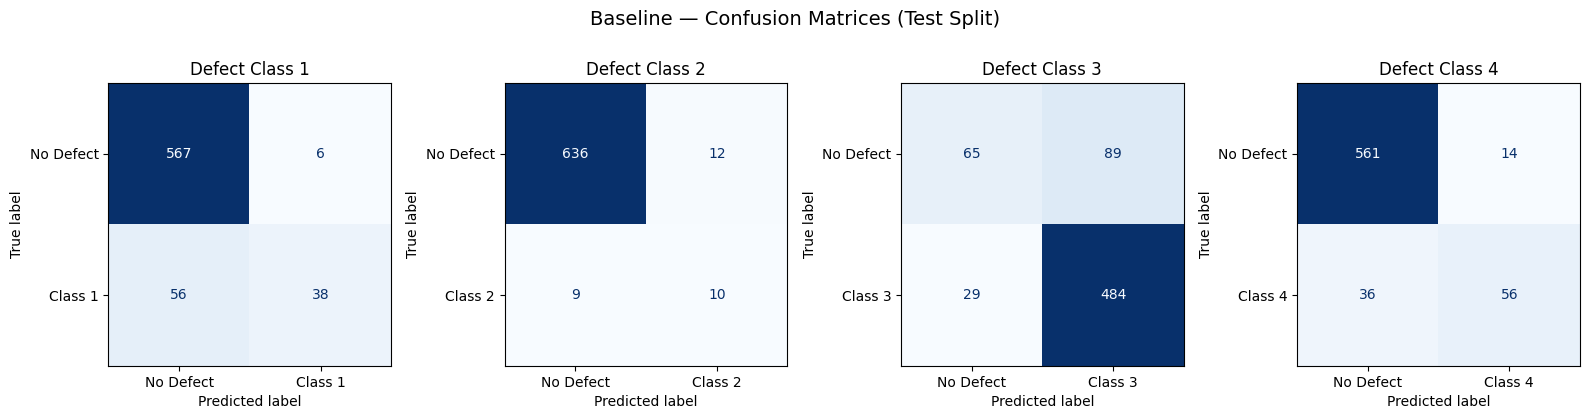


--- Discussion on Failure Cases ---
Off-diagonal cells indicate misclassifications:
  - Top-right: False Positives (predicted defect, but none present)
  - Bottom-left: False Negatives (missed an actual defect)
In a safety-critical welding environment, False Negatives are far more costly.
Consider lowering the THRESHOLD to improve Recall at the expense of Precision.


In [23]:
# --- Per-class binary confusion matrices (failure case analysis) ---
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 4))
for i, ax in enumerate(axes):
    cm = confusion_matrix(test_labels[:, i], test_preds[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Defect', f'Class {i+1}'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Defect Class {i+1}', fontsize=12)

plt.suptitle('Baseline — Confusion Matrices (Test Split)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n--- Discussion on Failure Cases ---")
print("Off-diagonal cells indicate misclassifications:")
print("  - Top-right: False Positives (predicted defect, but none present)")
print("  - Bottom-left: False Negatives (missed an actual defect)")
print("In a safety-critical welding environment, False Negatives are far more costly.")
print("Consider lowering the THRESHOLD to improve Recall at the expense of Precision.")

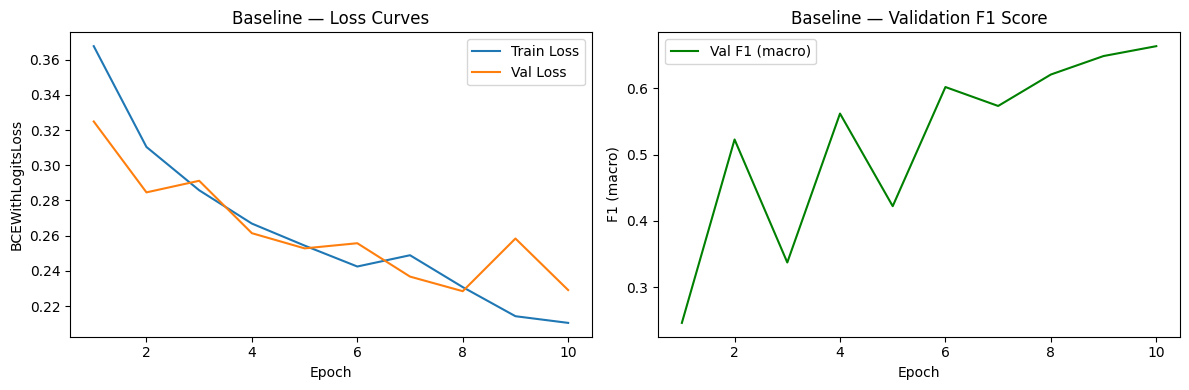

In [24]:
# --- Baseline training curves ---
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, baseline_history['train_loss'], label='Train Loss')
ax1.plot(epochs_range, baseline_history['val_loss'],   label='Val Loss')
ax1.set_title('Baseline — Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCEWithLogitsLoss')
ax1.legend()

ax2.plot(epochs_range, baseline_history['val_f1'], color='green', label='Val F1 (macro)')
ax2.set_title('Baseline — Validation F1 Score')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 (macro)')
ax2.legend()

plt.tight_layout()
plt.show()

---
# Transfer Learning (Experimental Setting 2)
We use a **ResNet-50** backbone pretrained on ImageNet and replace its classification head
for multi-label surface defect detection. **All backbone layers are frozen** — only the new
head is trained. This dramatically reduces training time and leverages features (edges,
textures, shapes) already learned from millions of natural images.

## Step 4 — Network Architecture (Transfer Learning)
Load a pretrained ResNet-50, freeze the entire backbone, and replace the final
fully-connected layer with a new head for 4-class multi-label output.

In [25]:
# Load pretrained ResNet-50 (modern weights API)
tl_backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze ALL backbone parameters
for param in tl_backbone.parameters():
    param.requires_grad = False

# Replace the classification head
# ResNet-50 fc layer: Linear(in_features=2048, out_features=1000)
# We replace it with our 4-class multi-label head
num_ftrs = tl_backbone.fc.in_features   # 2048
tl_backbone.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES),
    # NOTE: No Sigmoid — BCEWithLogitsLoss handles it for numerical stability.
)

tl_model = tl_backbone.to(device)

# Only optimise the new head parameters (backbone is frozen)
tl_criterion = nn.BCEWithLogitsLoss()
tl_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, tl_model.parameters()),
    lr=1e-4,   # Lower than baseline (1e-3) — head-only training
)

# Verify: count trainable vs total parameters
total_params     = sum(p.numel() for p in tl_model.parameters())
trainable_params = sum(p.numel() for p in tl_model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")
print(f"Frozen parameters:    {total_params - trainable_params:,}")
print(f"\nNew classification head:")
print(tl_model.fc)

Total parameters:     24,559,172
Trainable parameters: 1,051,140 (4.3%)
Frozen parameters:    23,508,032

New classification head:
Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=512, out_features=4, bias=True)
)


## Step 5 — Training Loop (Transfer Learning)
Same training loop structure as the baseline for a fair comparison.
Only the new classification head is updated since backbone gradients are disabled.

In [26]:
tl_history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

for epoch in range(EPOCHS):
    # ---- Training ----
    tl_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        tl_optimizer.zero_grad()
        logits = tl_model(images)
        loss   = tl_criterion(logits, labels)
        loss.backward()
        tl_optimizer.step()
        running_loss += loss.item()

    # ---- Validation ----
    tl_model.eval()
    val_loss  = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits = tl_model(images)
            val_loss += tl_criterion(logits, labels).item()
            preds = (torch.sigmoid(logits) >= THRESHOLD).cpu().numpy().astype(int)
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy().astype(int))

    all_preds  = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    train_loss_avg = running_loss / len(train_loader)
    val_loss_avg   = val_loss   / len(val_loader)

    tl_history['train_loss'].append(train_loss_avg)
    tl_history['val_loss'].append(val_loss_avg)
    tl_history['val_f1'].append(f1)

    print(
        f"Epoch [{epoch+1:>2}/{EPOCHS}] | "
        f"Train Loss: {train_loss_avg:.4f} | "
        f"Val Loss: {val_loss_avg:.4f} | "
        f"Val F1 (macro): {f1:.4f}"
    )

Epoch [ 1/10] | Train Loss: 0.3605 | Val Loss: 0.3111 | Val F1 (macro): 0.2234
Epoch [ 2/10] | Train Loss: 0.3000 | Val Loss: 0.2766 | Val F1 (macro): 0.3674
Epoch [ 3/10] | Train Loss: 0.2716 | Val Loss: 0.2546 | Val F1 (macro): 0.4269
Epoch [ 4/10] | Train Loss: 0.2595 | Val Loss: 0.2397 | Val F1 (macro): 0.4811
Epoch [ 5/10] | Train Loss: 0.2404 | Val Loss: 0.2284 | Val F1 (macro): 0.5277
Epoch [ 6/10] | Train Loss: 0.2297 | Val Loss: 0.2226 | Val F1 (macro): 0.5684
Epoch [ 7/10] | Train Loss: 0.2204 | Val Loss: 0.2175 | Val F1 (macro): 0.5454
Epoch [ 8/10] | Train Loss: 0.2148 | Val Loss: 0.2130 | Val F1 (macro): 0.5994
Epoch [ 9/10] | Train Loss: 0.2079 | Val Loss: 0.2073 | Val F1 (macro): 0.6280
Epoch [10/10] | Train Loss: 0.2035 | Val Loss: 0.2030 | Val F1 (macro): 0.5582


## Step 6 — Test Set Evaluation & Failure Case Analysis (Transfer Learning)
Same evaluation pipeline as the baseline. Compare results directly to quantify
the improvement gained from transfer learning.

In [27]:
tl_model.eval()
tl_test_preds  = []
tl_test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = tl_model(images)
        preds  = (torch.sigmoid(logits) >= THRESHOLD).cpu().numpy().astype(int)
        tl_test_preds.append(preds)
        tl_test_labels.append(labels.numpy().astype(int))

tl_test_preds  = np.vstack(tl_test_preds)
tl_test_labels = np.vstack(tl_test_labels)

tl_precision = precision_score(tl_test_labels, tl_test_preds, average='macro', zero_division=0)
tl_recall    = recall_score(tl_test_labels, tl_test_preds, average='macro', zero_division=0)
tl_f1_macro  = f1_score(tl_test_labels, tl_test_preds, average='macro', zero_division=0)

print("--- Transfer Learning: Final Test Metrics (macro-averaged) ---")
print(f"F1-Score  (macro): {tl_f1_macro:.4f}")
print(f"Precision (macro): {tl_precision:.4f}")
print(f"Recall    (macro): {tl_recall:.4f}")

# Per-class breakdown
print("\n--- Per-Class Metrics ---")
for i, cls in enumerate(CLASS_NAMES):
    p = precision_score(tl_test_labels[:, i], tl_test_preds[:, i], zero_division=0)
    r = recall_score(tl_test_labels[:, i], tl_test_preds[:, i], zero_division=0)
    f = f1_score(tl_test_labels[:, i], tl_test_preds[:, i], zero_division=0)
    print(f"  {cls}: Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}")

# --- Side-by-side comparison ---
print("\n" + "="*50)
print("COMPARISON: Baseline vs Transfer Learning")
print("="*50)
print(f"{'Metric':<20} {'Baseline':>10} {'TL (ResNet-50)':>15}")
print(f"{'-'*20} {'-'*10} {'-'*15}")
print(f"{'F1 (macro)':<20} {f1_macro:>10.4f} {tl_f1_macro:>15.4f}")
print(f"{'Precision (macro)':<20} {precision:>10.4f} {tl_precision:>15.4f}")
print(f"{'Recall (macro)':<20} {recall:>10.4f} {tl_recall:>15.4f}")

--- Transfer Learning: Final Test Metrics (macro-averaged) ---
F1-Score  (macro): 0.6283
Precision (macro): 0.8733
Recall    (macro): 0.5419

--- Per-Class Metrics ---
  Class 1: Precision=0.943  Recall=0.532  F1=0.680
  Class 2: Precision=0.750  Recall=0.158  F1=0.261
  Class 3: Precision=0.860  Recall=0.967  F1=0.910
  Class 4: Precision=0.940  Recall=0.511  F1=0.662

COMPARISON: Baseline vs Transfer Learning
Metric                 Baseline  TL (ResNet-50)
-------------------- ---------- ---------------
F1 (macro)               0.6553          0.6283
Precision (macro)        0.7407          0.8733
Recall (macro)           0.6207          0.5419


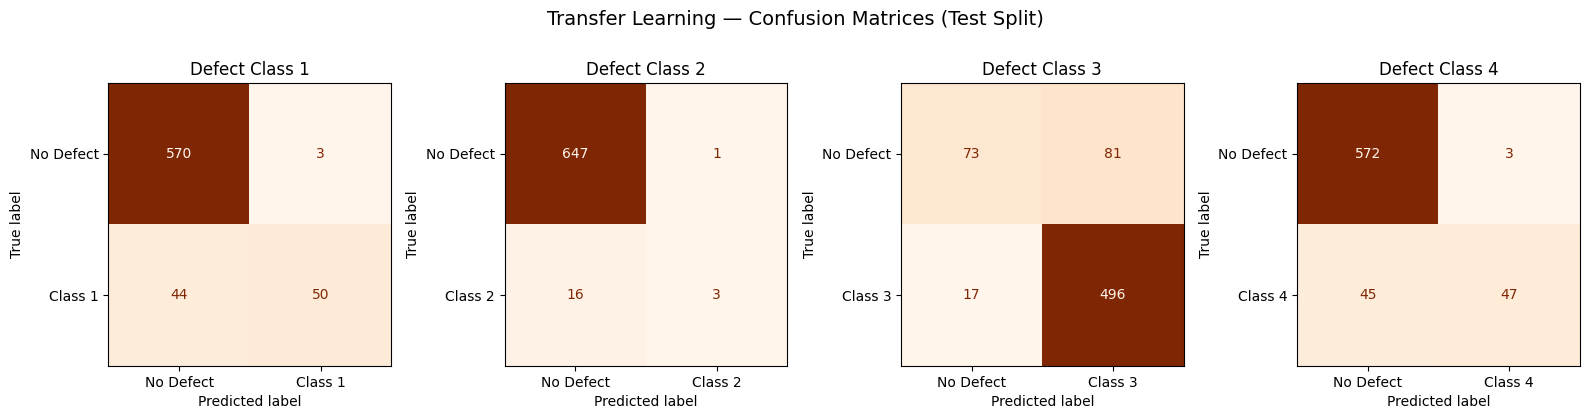


--- Discussion ---
Compare these confusion matrices against the baseline CNN results above.
Transfer learning should show fewer off-diagonal cells, especially for rare defect classes.
The pretrained ResNet-50 features (edges, textures, shapes) transfer well to industrial surfaces.


In [28]:
# --- Per-class binary confusion matrices (Transfer Learning) ---
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 4))
for i, ax in enumerate(axes):
    cm = confusion_matrix(tl_test_labels[:, i], tl_test_preds[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Defect', f'Class {i+1}'])
    disp.plot(ax=ax, cmap='Oranges', colorbar=False)
    ax.set_title(f'Defect Class {i+1}', fontsize=12)

plt.suptitle('Transfer Learning — Confusion Matrices (Test Split)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n--- Discussion ---")
print("Compare these confusion matrices against the baseline CNN results above.")
print("Transfer learning should show fewer off-diagonal cells, especially for rare defect classes.")
print("The pretrained ResNet-50 features (edges, textures, shapes) transfer well to industrial surfaces.")

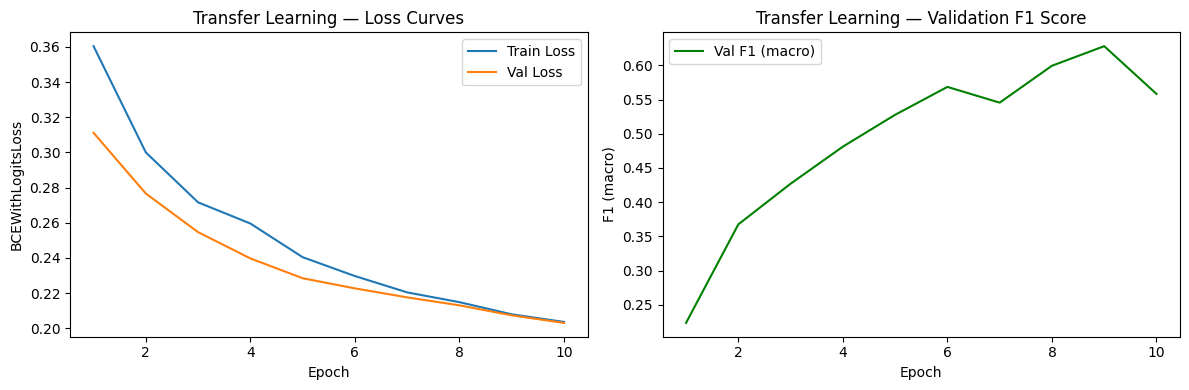

In [29]:
# --- Transfer Learning training curves ---
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, tl_history['train_loss'], label='Train Loss')
ax1.plot(epochs_range, tl_history['val_loss'],   label='Val Loss')
ax1.set_title('Transfer Learning — Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCEWithLogitsLoss')
ax1.legend()

ax2.plot(epochs_range, tl_history['val_f1'], color='green', label='Val F1 (macro)')
ax2.set_title('Transfer Learning — Validation F1 Score')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 (macro)')
ax2.legend()

plt.tight_layout()
plt.show()

---
# Fine-Tuning with Aggressive Augmentation (Experimental Setting 3)
We **unfreeze** the ResNet-50 backbone and apply **aggressive data augmentation** designed
to simulate the chaotic lighting, dirt, and visual noise of a real-world mining/welding
environment. This tests whether domain-adapted fine-tuning can outperform frozen transfer
learning.

Key differences from Setting 2:
- All backbone layers are **unfrozen** (full end-to-end training)
- **Differential learning rates**: backbone at `1e-5`, head at `1e-4`
- **Aggressive augmentation pipeline**: random resized crops, heavy colour jitter, Gaussian blur, random grayscale, and random erasing to simulate occlusions

## Step 4 — Aggressive Augmentation Pipeline
This augmentation pipeline is explicitly designed to simulate a rugged industrial
environment: erratic lighting (heavy brightness/contrast jitter), sensor noise
(Gaussian blur), partial occlusion by dirt or spatter (random erasing), and
varying camera angles (random resized crops).

In [30]:
# Aggressive augmentation — simulates rugged mining/welding conditions
ft_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), ratio=(0.8, 1.2)),  # varying camera angle/distance
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(
        brightness=0.4,   # erratic industrial lighting
        contrast=0.4,     # shadows from machinery
        saturation=0.3,   # dust/grime desaturation
        hue=0.1,          # colour cast from welding arcs
    ),
    transforms.RandomGrayscale(p=0.1),          # occasional greyscale sensor feed
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),  # sensor noise / vibration blur
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),  # dirt/spatter occlusion
])

# Rebuild train loader with aggressive augmentations
ft_train_dataset = SteelDefectDataset(TRAIN_CSV, IMG_DIR, transform=ft_train_transform)
ft_train_loader  = DataLoader(ft_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)

print(f"Fine-tuning train set: {len(ft_train_dataset)} images (with aggressive augmentation)")
print(f"Val/Test loaders reused from above (no augmentation).")

Fine-tuning train set: 5332 images (with aggressive augmentation)
Val/Test loaders reused from above (no augmentation).


## Step 5 — Network Architecture (Fine-Tuning)
Load a fresh ResNet-50, **unfreeze all layers**, and use differential learning rates:
- Backbone: `1e-5` (gentle updates to preserve pretrained features)
- Head: `1e-4` (faster adaptation to our task)

In [31]:
# Load a fresh pretrained ResNet-50
ft_backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Replace the classification head (same structure as Setting 2)
num_ftrs = ft_backbone.fc.in_features  # 2048
ft_backbone.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES),
)

ft_model = ft_backbone.to(device)

# ALL parameters are unfrozen (full fine-tuning)
# Use differential learning rates: backbone gets a much lower LR
backbone_params = [p for name, p in ft_model.named_parameters() if 'fc' not in name]
head_params     = [p for name, p in ft_model.named_parameters() if 'fc' in name]

ft_criterion = nn.BCEWithLogitsLoss()
ft_optimizer = optim.Adam([
    {'params': backbone_params, 'lr': 1e-5},   # backbone: gentle fine-tuning
    {'params': head_params,     'lr': 1e-4},   # head: faster adaptation
])

total_params     = sum(p.numel() for p in ft_model.parameters())
trainable_params = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%) — ALL unfrozen")
print(f"Backbone LR: 1e-5 | Head LR: 1e-4")
print(f"\nClassification head:")
print(ft_model.fc)

Total parameters:     24,559,172
Trainable parameters: 24,559,172 (100.0%) — ALL unfrozen
Backbone LR: 1e-5 | Head LR: 1e-4

Classification head:
Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=512, out_features=4, bias=True)
)


## Step 6 — Training Loop (Fine-Tuning)
Full end-to-end training with the aggressive augmentation pipeline.
The backbone's pretrained features are gently adapted to our steel defect domain.

In [32]:
ft_history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

for epoch in range(EPOCHS):
    # ---- Training (with aggressive augmentation) ----
    ft_model.train()
    running_loss = 0.0
    for images, labels in ft_train_loader:
        images, labels = images.to(device), labels.to(device)
        ft_optimizer.zero_grad()
        logits = ft_model(images)
        loss   = ft_criterion(logits, labels)
        loss.backward()
        ft_optimizer.step()
        running_loss += loss.item()

    # ---- Validation (no augmentation) ----
    ft_model.eval()
    val_loss   = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits = ft_model(images)
            val_loss += ft_criterion(logits, labels).item()
            preds = (torch.sigmoid(logits) >= THRESHOLD).cpu().numpy().astype(int)
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy().astype(int))

    all_preds  = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    train_loss_avg = running_loss / len(ft_train_loader)
    val_loss_avg   = val_loss   / len(val_loader)

    ft_history['train_loss'].append(train_loss_avg)
    ft_history['val_loss'].append(val_loss_avg)
    ft_history['val_f1'].append(f1)

    print(
        f"Epoch [{epoch+1:>2}/{EPOCHS}] | "
        f"Train Loss: {train_loss_avg:.4f} | "
        f"Val Loss: {val_loss_avg:.4f} | "
        f"Val F1 (macro): {f1:.4f}"
    )

Epoch [ 1/10] | Train Loss: 0.3680 | Val Loss: 0.3493 | Val F1 (macro): 0.2171
Epoch [ 2/10] | Train Loss: 0.3009 | Val Loss: 0.3329 | Val F1 (macro): 0.2173
Epoch [ 3/10] | Train Loss: 0.2723 | Val Loss: 0.3118 | Val F1 (macro): 0.2340
Epoch [ 4/10] | Train Loss: 0.2511 | Val Loss: 0.3537 | Val F1 (macro): 0.2345
Epoch [ 5/10] | Train Loss: 0.2358 | Val Loss: 0.3549 | Val F1 (macro): 0.2494
Epoch [ 6/10] | Train Loss: 0.2271 | Val Loss: 0.3599 | Val F1 (macro): 0.2620
Epoch [ 7/10] | Train Loss: 0.2169 | Val Loss: 0.3555 | Val F1 (macro): 0.2917
Epoch [ 8/10] | Train Loss: 0.2073 | Val Loss: 0.3525 | Val F1 (macro): 0.2835
Epoch [ 9/10] | Train Loss: 0.2017 | Val Loss: 0.3690 | Val F1 (macro): 0.3069
Epoch [10/10] | Train Loss: 0.1957 | Val Loss: 0.3827 | Val F1 (macro): 0.2966


## Step 7 — Test Set Evaluation & Failure Case Analysis (Fine-Tuning)
Final evaluation on the held-out test split. Results are compared against
both the baseline CNN and frozen transfer learning.

In [33]:
ft_model.eval()
ft_test_preds  = []
ft_test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = ft_model(images)
        preds  = (torch.sigmoid(logits) >= THRESHOLD).cpu().numpy().astype(int)
        ft_test_preds.append(preds)
        ft_test_labels.append(labels.numpy().astype(int))

ft_test_preds  = np.vstack(ft_test_preds)
ft_test_labels = np.vstack(ft_test_labels)

ft_precision = precision_score(ft_test_labels, ft_test_preds, average='macro', zero_division=0)
ft_recall    = recall_score(ft_test_labels, ft_test_preds, average='macro', zero_division=0)
ft_f1_macro  = f1_score(ft_test_labels, ft_test_preds, average='macro', zero_division=0)

print("--- Fine-Tuning: Final Test Metrics (macro-averaged) ---")
print(f"F1-Score  (macro): {ft_f1_macro:.4f}")
print(f"Precision (macro): {ft_precision:.4f}")
print(f"Recall    (macro): {ft_recall:.4f}")

# Per-class breakdown
print("\n--- Per-Class Metrics ---")
for i, cls in enumerate(CLASS_NAMES):
    p = precision_score(ft_test_labels[:, i], ft_test_preds[:, i], zero_division=0)
    r = recall_score(ft_test_labels[:, i], ft_test_preds[:, i], zero_division=0)
    f = f1_score(ft_test_labels[:, i], ft_test_preds[:, i], zero_division=0)
    print(f"  {cls}: Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}")

# --- Three-way comparison ---
print("\n" + "="*65)
print("COMPARISON: All Three Experimental Settings")
print("="*65)
print(f"{'Metric':<20} {'Baseline':>10} {'TL (frozen)':>12} {'FT (unfrozen)':>14}")
print(f"{'-'*20} {'-'*10} {'-'*12} {'-'*14}")
print(f"{'F1 (macro)':<20} {f1_macro:>10.4f} {tl_f1_macro:>12.4f} {ft_f1_macro:>14.4f}")
print(f"{'Precision (macro)':<20} {precision:>10.4f} {tl_precision:>12.4f} {ft_precision:>14.4f}")
print(f"{'Recall (macro)':<20} {recall:>10.4f} {tl_recall:>12.4f} {ft_recall:>14.4f}")

--- Fine-Tuning: Final Test Metrics (macro-averaged) ---
F1-Score  (macro): 0.3346
Precision (macro): 0.5793
Recall    (macro): 0.3073

--- Per-Class Metrics ---
  Class 1: Precision=0.273  Recall=0.160  F1=0.201
  Class 2: Precision=0.333  Recall=0.053  F1=0.091
  Class 3: Precision=0.802  Recall=0.908  F1=0.852
  Class 4: Precision=0.909  Recall=0.109  F1=0.194

COMPARISON: All Three Experimental Settings
Metric                 Baseline  TL (frozen)  FT (unfrozen)
-------------------- ---------- ------------ --------------
F1 (macro)               0.6553       0.6283         0.3346
Precision (macro)        0.7407       0.8733         0.5793
Recall (macro)           0.6207       0.5419         0.3073


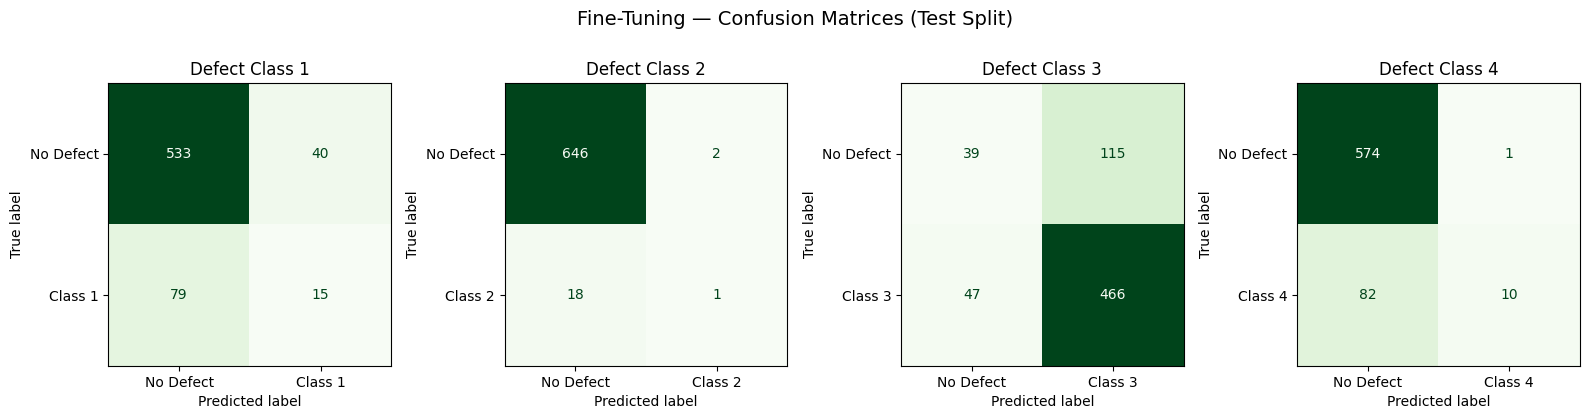


--- Discussion ---
Fine-tuning with aggressive augmentation is designed for rugged deployment environments.
The heavy augmentation (brightness jitter, blur, erasing) simulates dirt, vibration, and
chaotic lighting found in real mining and welding settings.
If FT outperforms frozen TL, it shows that domain-adapted features outperform generic ImageNet features.


In [34]:
# --- Per-class binary confusion matrices (Fine-Tuning) ---
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 4))
for i, ax in enumerate(axes):
    cm = confusion_matrix(ft_test_labels[:, i], ft_test_preds[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Defect', f'Class {i+1}'])
    disp.plot(ax=ax, cmap='Greens', colorbar=False)
    ax.set_title(f'Defect Class {i+1}', fontsize=12)

plt.suptitle('Fine-Tuning — Confusion Matrices (Test Split)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n--- Discussion ---")
print("Fine-tuning with aggressive augmentation is designed for rugged deployment environments.")
print("The heavy augmentation (brightness jitter, blur, erasing) simulates dirt, vibration, and")
print("chaotic lighting found in real mining and welding settings.")
print("If FT outperforms frozen TL, it shows that domain-adapted features outperform generic ImageNet features.")

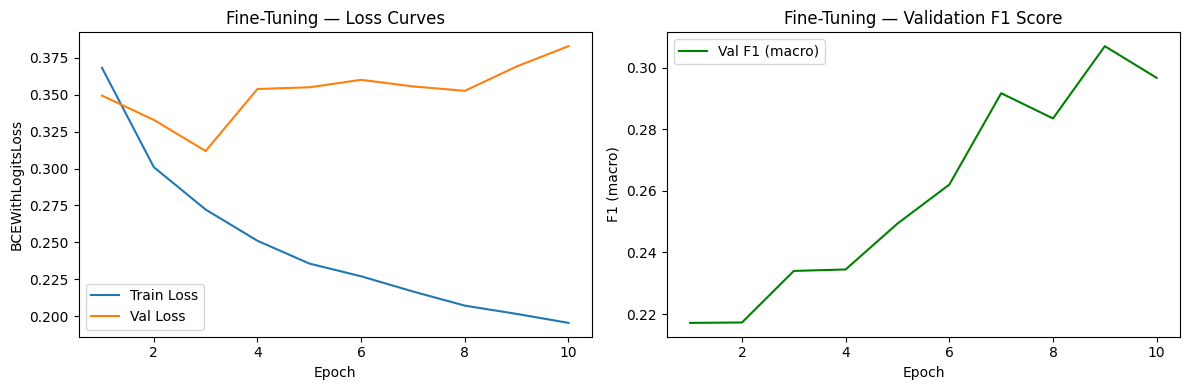

In [35]:
# --- Fine-Tuning training curves ---
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, ft_history['train_loss'], label='Train Loss')
ax1.plot(epochs_range, ft_history['val_loss'],   label='Val Loss')
ax1.set_title('Fine-Tuning — Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCEWithLogitsLoss')
ax1.legend()

ax2.plot(epochs_range, ft_history['val_f1'], color='green', label='Val F1 (macro)')
ax2.set_title('Fine-Tuning — Validation F1 Score')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 (macro)')
ax2.legend()

plt.tight_layout()
plt.show()